In [4]:
import pandas as pd 
import numpy as np
import cvxpy as cp
import math
import random
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

from conditionalconformal import CondConf
from conditionalconformal.condconf import setup_cvx_problem_calib

from sklearn.metrics.pairwise import pairwise_kernels

from ridge import setup_ridge_problem, runRidgeCV
from crossval import runCV
import mosek

%load_ext autoreload
%autoreload 2

In [5]:
def generateGaussData(nTrain,nTest,d,wZero=False):
    XTrain = np.random.normal(size=(nTrain,d))
    XTest = np.random.normal(size=(nTest,d))
    
    if wZero:
        w = np.zeros(d)
    else:
        w = np.random.normal(size=d)
        w = w/math.sqrt(sum(w**2))
    
    YTrain = XTrain@w + np.random.normal(size=nTrain)
    YTest = XTest@w + np.random.normal(size=nTest)
    
    XTrain = np.column_stack((np.ones(nTrain),XTrain))
    XTest = np.column_stack((np.ones(nTest),XTest))
    return XTrain, YTrain, XTest, YTest


In [3]:
### Compute effective sample size at the chosen kernel shifts 
XTrain, YTrain, XTest, YTest = generateGaussData(nTrain = 200,nTest=10,d=50)
shiftLocs = [0,1]
KShifts = pairwise_kernels(
    X = XTrain,
    Y = XTrain,
    metric='rbf',
    gamma=0.025
)
ESS1 = sum(KShifts[0,:])**2/sum(KShifts[0,:]**2)
ESS2 = sum(KShifts[1,:])**2/sum(KShifts[1,:]**2)
print(ESS1)
print(ESS2)


127.82510195083708
126.03748174666451


In [6]:
### Evaluate calibration-conditional coverage on one simulated example
def oneRidgeCVExperiment(nTrain, nTest, d, alpha, minRad, maxRad, numRad, fixed_radius = 0.5):
    ### Generate data
    XTrain, YTrain, XTest, YTest = generateGaussData(nTrain,nTest,d)
    radius_selected = runRidgeCV(XTrain[:,0].reshape(-1,1),XTrain[:,1:],YTrain,minRad,maxRad,numRad,alpha,k=5)
    #print(radius_selected)
    
    ### Evaluate CV coverage
    cvCov = 0
    for i in range(nTest):
        prob = setup_ridge_problem(1-alpha,np.row_stack((XTrain[:,0].reshape(-1,1),XTest[i,0].reshape(-1,1))),
                                   np.row_stack((XTrain[:,1:],XTest[i,1:])),np.append(YTrain,YTest[i]),radius_selected)
        prob.solve(
                solver='MOSEK', 
                verbose=False, 
                mosek_params={mosek.iparam.intpnt_solve_form: mosek.solveform.dual}
            )
        cvCov = cvCov + (prob.var_dict['weights'].value[-1] <= random.uniform(-alpha,1-alpha))/nTest
        
    ### Evaluate no CV coverage
    nonCvCov = 0
    for i in range(nTest):
        prob = setup_ridge_problem(1-alpha,np.row_stack((XTrain[:,0].reshape(-1,1),XTest[i,0].reshape(-1,1))),
                                   np.row_stack((XTrain[:,1:],XTest[i,1:])),np.append(YTrain,YTest[i]),fixed_radius)
        prob.solve(
                solver='MOSEK', 
                verbose=False, 
                mosek_params={mosek.iparam.intpnt_solve_form: mosek.solveform.dual}
            )
        nonCvCov = nonCvCov + (prob.var_dict['weights'].value[-1] <= random.uniform(-alpha,1-alpha))/nTest
        


                                                                         
    coverageData = pd.DataFrame({'Method': ['Fixed Regularization','Cross-Validated Regularization'],
                                'Coverage': [nonCvCov,cvCov]})
        
    return coverageData


nTrials = 20 
nTest = 100
nTrain = 200
d = 50
minRad = 0.001
maxRad = 0.5
numRad = 20

alpha = 0.1

coverageDF = pd.DataFrame()
for i in tqdm(range(nTrials)):
    appendDF = oneRidgeCVExperiment(nTrain,nTest,d,alpha, minRad, maxRad, numRad, fixed_radius = 0.1)

    appendDF['trial'] = i
    appendDF['Calibration Set Size'] = nTrain
    appendDF['Function Class Dimension'] = d
    coverageDF = pd.concat([coverageDF,appendDF]) 

In [7]:
### Evaluate calibration-conditional coverage on one simulated example
def oneKernelCVExperiment(nTrain,nTest,d,alpha, minRad, maxRad, numRad, gamma, k=5, fixed_radius = 0.5):
    ### Generate data
    XTrain, YTrain, XTest, YTest = generateGaussData(nTrain,nTest,d)
    allLosses, radii = runCV(XTrain[:,1:],YTrain,'rbf',gamma,alpha,k,minRad,maxRad,numRad,XTrain[:,0].reshape(-1,1))
    radius_selected = radii[np.argmin(allLosses)]
    print(radius_selected)
    
    ### Evaluate CV coverage
    cvCov = 0
    for i in range(nTest):
        prob = setup_cvx_problem_calib(1-alpha,np.row_stack((XTrain[:,1:],XTest[i,1:])),
                                       np.append(YTrain,YTest[i]),
                                       np.row_stack((XTrain[:,0].reshape(-1,1),XTest[i,0].reshape(-1,1))),
                                       {'kernel': 'rbf', 'gamma': gamma, 'lambda' : 1/radius_selected})
        prob.solve(solver="MOSEK",
                   verbose=False, 
                   mosek_params={mosek.iparam.intpnt_solve_form: mosek.solveform.dual})
        cvCov = cvCov + (prob.var_dict['weights'].value[-1] <= random.uniform(-alpha,1-alpha))/nTest

    
        
    ### Evaluate no CV coverage
    nonCvCov = 0
    for i in range(nTest):
        prob = setup_cvx_problem_calib(1-alpha,np.row_stack((XTrain[:,1:],XTest[i,1:])),
                                       np.append(YTrain,YTest[i]),
                                       np.row_stack((XTrain[:,0].reshape(-1,1),XTest[i,0].reshape(-1,1))),
                                       {'kernel': 'rbf', 'gamma': gamma, 'lambda' : 1/fixed_radius})
        prob.solve(solver="MOSEK",
                   verbose=False, 
                   mosek_params={mosek.iparam.intpnt_solve_form: mosek.solveform.dual})
        nonCvCov = nonCvCov + (prob.var_dict['weights'].value[-1] <= random.uniform(-alpha,1-alpha))/nTest
        


                                                                         
    coverageData = pd.DataFrame({'Method': ['Fixed Regularization','Cross-Validated Regularization'],
                                'Coverage': [nonCvCov,cvCov]})
        
    return coverageData

nTrials = 20
nTest = 100
nTrain = 200
d = 50
minRad = 0.001
maxRad = 0.6
numRad = 20
gamma = 0.025

alpha = 0.1

coverageDFKernel = pd.DataFrame()
for i in tqdm(range(nTrials)):
    appendDF = oneKernelCVExperiment(nTrain,nTest,d,alpha, minRad, maxRad, numRad, gamma, fixed_radius = 0.35)

    appendDF['trial'] = i
    appendDF['Calibration Set Size'] = nTrain
    appendDF['Function Class Dimension'] = d
    coverageDFKernel = pd.concat([coverageDF,appendDF]) 

0
1
2
3


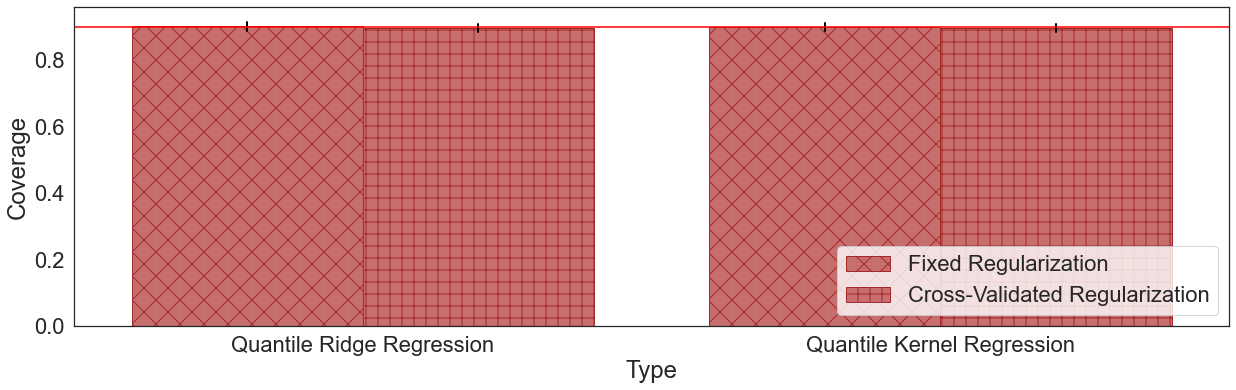

In [8]:
### Plot Results 
sns.set(rc={'figure.figsize':(20.7,5.87)})
sns.set(font_scale=2)
sns.set_style(style='white')
fig = plt.figure()

my_pal = {"Cross-Validated Regularization": sns.color_palette("muted")[:][3],
         "Fixed Regularization": sns.color_palette("muted")[:][3]}
coverageDF['Type'] = len(coverageDF)*['Quantile Ridge Regression']
coverageDFKernel['Type'] = len(coverageDFKernel)*['Quantile Kernel Regression']
allCoverageDF = pd.concat([coverageDF,coverageDFKernel])

f = sns.barplot(allCoverageDF,x='Type',y='Coverage', hue='Method', palette = my_pal)
    
hatches = ['x','x','+','+','x','+','','','']
colors = ['brown']*6

# Loop over the bars
for i,thisbar in enumerate(f.patches):
    print(i)
    # Set a different hatch for each bar
    thisbar.set_hatch(hatches[i])
    thisbar.set_edgecolor(colors[i])
    
# for i, artist in enumerate(plt.gca().artists):
#     print(i)
#     # Set hatch pattern
#     artist.set_hatch(hatches[i])
#     # Set edge color to change the color of the hatch lines
#     artist.set_edgecolor(colors[i])
# f.lines[4].set_linewidth(3)
# f.lines[10].set_linewidth(3)
# f.lines[16].set_linewidth(3)
# f.lines[22].set_linewidth(3)
# f.lines[4].set_color('black')
# f.lines[10].set_color('black')
# f.lines[16].set_color('black')
# f.lines[22].set_color('black')

for line in f.lines:
    line.set_linewidth(2)  # Set the width to 2 points
    line.set_color('black')



f.axhline(1-alpha, color='red')
plt.legend(title='')
plt.legend(loc='lower right')

plt.savefig('figures/CoverageCVvsNoCV.pdf')

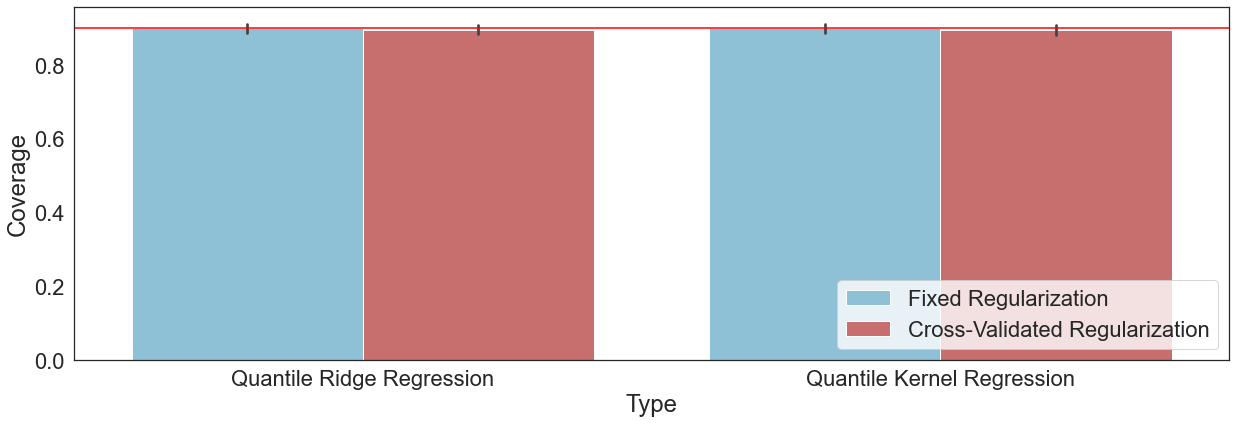

In [9]:
sns.set(rc={'figure.figsize':(20.7,6.5)})
sns.set(font_scale=2)
sns.set_style(style='white')
fig = plt.figure()

my_pal = {"Cross-Validated Regularization": sns.color_palette("muted")[:][3],
         "Fixed Regularization": sns.color_palette("muted")[:][9]}
coverageDF['Type'] = len(coverageDF)*['Quantile Ridge Regression']
coverageDFKernel['Type'] = len(coverageDFKernel)*['Quantile Kernel Regression']
allCoverageDF = pd.concat([coverageDF,coverageDFKernel])

f = sns.barplot(allCoverageDF,x='Type',y='Coverage', hue='Method', palette = my_pal)

f.axhline(1-alpha, color='red')
plt.legend(title='')
plt.legend(loc='lower right')

plt.savefig('figures/CoverageCVvsNoCV.pdf')

In [10]:
allCoverageDF.groupby(['Method','Type']).mean()

Coverage     trial  \
Method                         Type                                             
Cross-Validated Regularization Quantile Kernel Regression  0.894762  9.952381   
                               Quantile Ridge Regression   0.896000  9.500000   
Fixed Regularization           Quantile Kernel Regression  0.899524  9.952381   
                               Quantile Ridge Regression   0.901000  9.500000   

                                                           Calibration Set Size  \
Method                         Type                                               
Cross-Validated Regularization Quantile Kernel Regression                 200.0   
                               Quantile Ridge Regression                  200.0   
Fixed Regularization           Quantile Kernel Regression                 200.0   
                               Quantile Ridge Regression                  200.0   

                                                           Function Class Dimension  
Method                         Type                                                  
Cross-Validated Regularization Quantile Kernel Regression                      50.0  
                               Quantile Ridge Regression                       50.0  
Fixed Regularization           Quantile Kernel Regression                      50.0  
                               Quantile Ridge Regression                       50.0

In [15]:
1.96*allCoverageDF.groupby(['Method','Type']).std()/np.sqrt(20)

Coverage     trial  \
Method                         Type                                             
Cross-Validated Regularization Quantile Kernel Regression  0.012673  2.685544   
                               Quantile Ridge Regression   0.012750  2.592836   
Fixed Regularization           Quantile Kernel Regression  0.013110  2.685544   
                               Quantile Ridge Regression   0.013102  2.592836   

                                                           Calibration Set Size  \
Method                         Type                                               
Cross-Validated Regularization Quantile Kernel Regression                   0.0   
                               Quantile Ridge Regression                    0.0   
Fixed Regularization           Quantile Kernel Regression                   0.0   
                               Quantile Ridge Regression                    0.0   

                                                           Function Class Dimension  
Method                         Type                                                  
Cross-Validated Regularization Quantile Kernel Regression                       0.0  
                               Quantile Ridge Regression                        0.0  
Fixed Regularization           Quantile Kernel Regression                       0.0  
                               Quantile Ridge Regression                        0.0